In [1]:
#Demand Generators

import numpy as np

class StationaryDemand:
    """Poisson demand with a fixed rate (lambda)."""
    
    def __init__(self, mean_demand=20):
        self.mean_demand = mean_demand
    
    def sample(self, t, rng):
        return int(rng.poisson(self.mean_demand))
    
    def __repr__(self):
        return f"StationaryDemand(mean={self.mean_demand})"


class SeasonalDemand:
    """Poisson demand with a sinusoidal seasonal pattern."""
    
    def __init__(self, base_demand=20, amplitude=10, period=50):
        self.base_demand = base_demand
        self.amplitude = amplitude
        self.period = period  # number of time steps for one full cycle
    
    def sample(self, t, rng):
        # Lambda varies sinusoidally, floored at 1 to keep it valid
        seasonal_mean = self.base_demand + self.amplitude * np.sin(2 * np.pi * t / self.period)
        seasonal_mean = max(seasonal_mean, 1.0)
        return int(rng.poisson(seasonal_mean))
    
    def __repr__(self):
        return (f"SeasonalDemand(base={self.base_demand}, "
                f"amplitude={self.amplitude}, period={self.period})")


class TrendDemand:
    """Poisson demand with a linear drift over time."""
    
    def __init__(self, start_demand=15, drift_per_step=0.05):
        self.start_demand = start_demand
        self.drift_per_step = drift_per_step  # demand increases by this much each period
    
    def sample(self, t, rng):
        trending_mean = self.start_demand + self.drift_per_step * t
        trending_mean = max(trending_mean, 1.0)
        return int(rng.poisson(trending_mean))
    
    def __repr__(self):
        return (f"TrendDemand(start={self.start_demand}, "
                f"drift={self.drift_per_step}/step)")

In [2]:
# The Environment 
import gymnasium as gym
from gymnasium import spaces

class InventoryEnv(gym.Env):
    """
    Retail inventory management environment.
    
    The agent decides how much to order each period. Orders arrive immediately
    (zero lead time). Unfulfilled demand is lost (lost-sales model).
    
    Observation: [inventory_level, demand_{t-1}, ..., demand_{t-k}, time_feature]
    Action:      discrete index mapping to an order quantity
    Reward:      negative total cost (holding + stockout + ordering)
    """
    
    metadata = {"render_modes": []}
    
    def __init__(
        self,
        demand_generator=None,
        episode_length=100,
        max_inventory=200,
        max_order=100,
        order_step=5,          # granularity: actions are 0, 5, 10, ..., max_order
        holding_cost=1.0,
        stockout_cost=5.0,
        order_cost=0.5,
        initial_inventory=50,
        demand_history_len=4,  # how many past demands to include in the state
    ):
        super().__init__()
        
        # Store config
        self.demand_gen = demand_generator or StationaryDemand()
        self.episode_length = episode_length
        self.max_inventory = max_inventory
        self.max_order = max_order
        self.order_step = order_step
        self.holding_cost = holding_cost
        self.stockout_cost = stockout_cost
        self.order_cost = order_cost
        self.initial_inventory = initial_inventory
        self.demand_history_len = demand_history_len
        
        # Build the discrete action map: [0, order_step, 2*order_step, ..., max_order]
        self.action_to_quantity = list(range(0, max_order + 1, order_step))
        
        # --- Gymnasium spaces ---
        # Action: index into action_to_quantity
        self.action_space = spaces.Discrete(len(self.action_to_quantity))
        
        # Observation: [inventory, demand_hist..., time_feature]
        # inventory is in [-max_inventory, max_inventory] (negative = unmet demand this period)
        # demands are non-negative integers
        # time_feature is in [0, 1]
        obs_size = 1 + self.demand_history_len + 1  # inventory + history + time
        low = np.array(
            [-self.max_inventory]      # inventory can be negative conceptually,
            + [0] * self.demand_history_len  # demands are >= 0
            + [0.0],                        # time feature
            dtype=np.float32
        )
        high = np.array(
            [self.max_inventory]
            + [self.max_inventory] * self.demand_history_len  # generous upper bound
            + [1.0],
            dtype=np.float32
        )
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        
        # Will be set in reset()
        self.inventory = None
        self.t = None
        self.demand_history = None
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.inventory = self.initial_inventory
        self.t = 0
        self.demand_history = [0] * self.demand_history_len  # no history at start
        
        return self._get_obs(), self._get_info()
    
    def step(self, action):
        # Decode action
        order_qty = self.action_to_quantity[action]
        
        # Receive order (zero lead time)
        self.inventory += order_qty
        
        # Cap inventory at max (warehouse capacity)
        self.inventory = min(self.inventory, self.max_inventory)
        
        # Realize demand
        demand = self.demand_gen.sample(self.t, self.np_random)
        
        # Compute costs BEFORE updating inventory
        units_sold = min(self.inventory, demand)
        leftover_inventory = self.inventory - units_sold
        unmet_demand = demand - units_sold
        
        holding = self.holding_cost * leftover_inventory
        stockout = self.stockout_cost * unmet_demand
        ordering = self.order_cost * order_qty
        total_cost = holding + stockout + ordering
        
        # Update state
        self.inventory = leftover_inventory  # unsold units carry over
        self.t += 1
        
        # Update demand history (sliding window)
        self.demand_history.append(demand)
        self.demand_history = self.demand_history[-self.demand_history_len:]
        
        # Reward is negative cost (agent maximizes reward = minimizes cost)
        reward = -total_cost
        
        # Episode ends after episode_length periods
        terminated = False
        truncated = self.t >= self.episode_length
        
        info = self._get_info()
        info.update({
            "demand": demand,
            "order_qty": order_qty,
            "units_sold": units_sold,
            "unmet_demand": unmet_demand,
            "holding_cost": holding,
            "stockout_cost": stockout,
            "ordering_cost": ordering,
            "total_cost": total_cost,
        })
        
        return self._get_obs(), reward, terminated, truncated, info
    
    def _get_obs(self):
        time_feature = self.t / self.episode_length  # normalized to [0, 1]
        obs = np.array(
            [self.inventory] + self.demand_history + [time_feature],
            dtype=np.float32
        )
        return obs
    
    def _get_info(self):
        return {
            "inventory": self.inventory,
            "time_step": self.t,
            "demand_generator": str(self.demand_gen),
        }

Gymnasium env check passed.
Stable-Baselines3 env check passed.


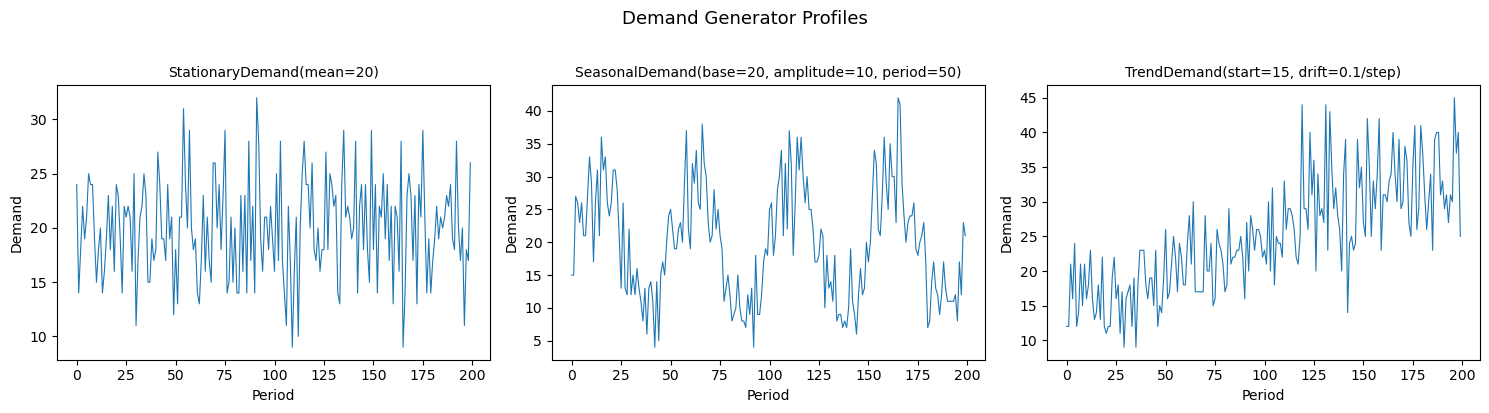

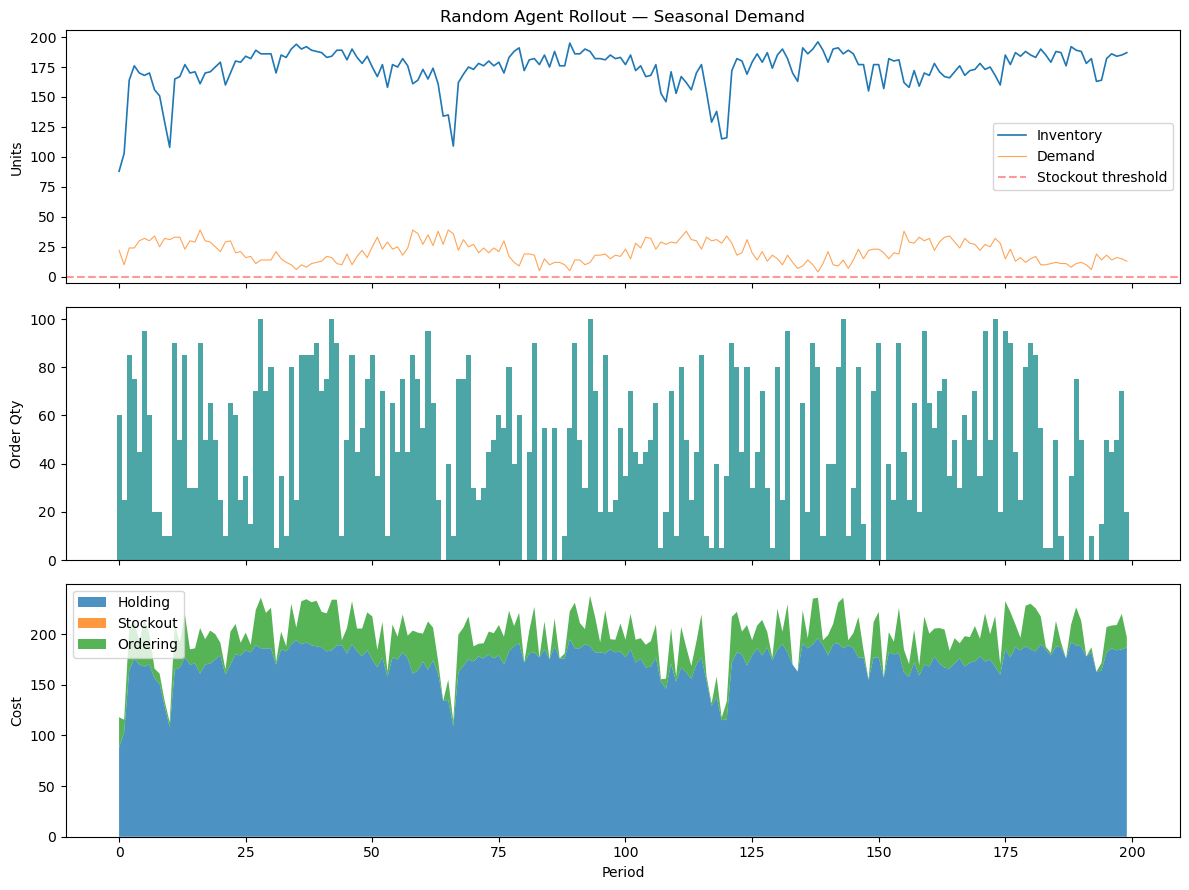


--- Random Agent Summary ---
Total cost:        39682.00
  Holding cost:    34757.00
  Stockout cost:   0.00
  Ordering cost:   4925.00
Stockout periods:  0/200 (0.0%)
Avg inventory:     173.8
Service level:     100.0%


In [3]:
# Validation and Sanity Checks 
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Check Gymnasium compatibility
# ------------------------------------------------------------------
from gymnasium.utils.env_checker import check_env

env = InventoryEnv()
check_env(env.unwrapped, skip_render_check=True)
print("Gymnasium env check passed.")

# ------------------------------------------------------------------
# 2. Check Stable-Baselines3 compatibility
# ------------------------------------------------------------------
from stable_baselines3.common.env_checker import check_env as sb3_check_env

sb3_check_env(env)
print("Stable-Baselines3 env check passed.")

# ------------------------------------------------------------------
# 3. Visualize demand generators
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

generators = [
    StationaryDemand(mean_demand=20),
    SeasonalDemand(base_demand=20, amplitude=10, period=50),
    TrendDemand(start_demand=15, drift_per_step=0.1),
]

viz_rng = np.random.default_rng(42)

for ax, gen in zip(axes, generators):
    demands = [gen.sample(t, viz_rng) for t in range(200)]
    ax.plot(demands, linewidth=0.8)
    ax.set_title(str(gen), fontsize=10)
    ax.set_xlabel("Period")
    ax.set_ylabel("Demand")

fig.suptitle("Demand Generator Profiles", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Run a random agent and plot the rollout
# ------------------------------------------------------------------
env = InventoryEnv(
    demand_generator=SeasonalDemand(base_demand=20, amplitude=10, period=50),
    episode_length=200,
)

obs, info = env.reset(seed=0)

# Track everything
inventories, demands, orders, rewards = [], [], [], []
holding_costs, stockout_costs, ordering_costs = [], [], []

done = False
while not done:
    action = env.action_space.sample()  # random policy
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    
    inventories.append(info["inventory"])
    demands.append(info["demand"])
    orders.append(info["order_qty"])
    rewards.append(reward)
    holding_costs.append(info["holding_cost"])
    stockout_costs.append(info["stockout_cost"])
    ordering_costs.append(info["ordering_cost"])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Inventory and demand
axes[0].plot(inventories, label="Inventory", linewidth=1.2)
axes[0].plot(demands, label="Demand", alpha=0.7, linewidth=0.8)
axes[0].axhline(y=0, color="red", linestyle="--", alpha=0.4, label="Stockout threshold")
axes[0].set_ylabel("Units")
axes[0].legend()
axes[0].set_title("Random Agent Rollout — Seasonal Demand")

# Order quantities
axes[1].bar(range(len(orders)), orders, width=1.0, alpha=0.7, color="teal")
axes[1].set_ylabel("Order Qty")

# Cost breakdown
axes[2].stackplot(
    range(len(holding_costs)),
    holding_costs, stockout_costs, ordering_costs,
    labels=["Holding", "Stockout", "Ordering"],
    alpha=0.8
)
axes[2].set_ylabel("Cost")
axes[2].set_xlabel("Period")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

# Summary stats
total_cost = sum(holding_costs) + sum(stockout_costs) + sum(ordering_costs)
stockout_periods = sum(1 for s in stockout_costs if s > 0)
print(f"\n--- Random Agent Summary ---")
print(f"Total cost:        {total_cost:.2f}")
print(f"  Holding cost:    {sum(holding_costs):.2f}")
print(f"  Stockout cost:   {sum(stockout_costs):.2f}")
print(f"  Ordering cost:   {sum(ordering_costs):.2f}")
print(f"Stockout periods:  {stockout_periods}/{len(demands)} ({100*stockout_periods/len(demands):.1f}%)")
print(f"Avg inventory:     {np.mean(inventories):.1f}")
print(f"Service level:     {100*(1 - stockout_periods/len(demands)):.1f}%")

Force-testing the stockout penalty path since it did not get triggered above (0 stockout cost result). Below is a short episode with a never order policy

In [4]:
env = InventoryEnv(
    demand_generator=StationaryDemand(mean_demand=20),
    episode_length=20,
)
obs, info = env.reset(seed=0)

for t in range(20):
    obs, reward, terminated, truncated, info = env.step(0)  # action 0 = order nothing
    print(f"t={t:2d}  inventory={info['inventory']:4d}  "
          f"demand={info['demand']:3d}  "
          f"stockout_cost={info['stockout_cost']:.0f}  "
          f"holding_cost={info['holding_cost']:.0f}")

t= 0  inventory=  28  demand= 22  stockout_cost=0  holding_cost=28
t= 1  inventory=  19  demand=  9  stockout_cost=0  holding_cost=19
t= 2  inventory=   0  demand= 21  stockout_cost=10  holding_cost=0
t= 3  inventory=   0  demand= 25  stockout_cost=125  holding_cost=0
t= 4  inventory=   0  demand= 26  stockout_cost=130  holding_cost=0
t= 5  inventory=   0  demand= 23  stockout_cost=115  holding_cost=0
t= 6  inventory=   0  demand= 26  stockout_cost=130  holding_cost=0
t= 7  inventory=   0  demand= 17  stockout_cost=85  holding_cost=0
t= 8  inventory=   0  demand= 22  stockout_cost=110  holding_cost=0
t= 9  inventory=   0  demand= 21  stockout_cost=105  holding_cost=0
t=10  inventory=   0  demand= 22  stockout_cost=110  holding_cost=0
t=11  inventory=   0  demand= 23  stockout_cost=115  holding_cost=0
t=12  inventory=   0  demand= 14  stockout_cost=70  holding_cost=0
t=13  inventory=   0  demand= 20  stockout_cost=100  holding_cost=0
t=14  inventory=   0  demand= 20  stockout_cost=100  

In [5]:
# Environment Presets
def make_stationary_env(seed=None):
    """Scenario 1: Stable Poisson demand (mean=20). Baseline comparison scenario."""
    return InventoryEnv(
        demand_generator=StationaryDemand(mean_demand=20),
        episode_length=200,
        max_inventory=200,
        max_order=100,
        order_step=5,
        holding_cost=1.0,
        stockout_cost=5.0,
        order_cost=0.5,
        initial_inventory=50,
        demand_history_len=4,
    )


def make_seasonal_env(seed=None):
    """Scenario 2: Seasonal sinusoidal demand. Tests adaptation to cyclical shifts."""
    return InventoryEnv(
        demand_generator=SeasonalDemand(base_demand=20, amplitude=10, period=50),
        episode_length=200,
        max_inventory=200,
        max_order=100,
        order_step=5,
        holding_cost=1.0,
        stockout_cost=5.0,
        order_cost=0.5,
        initial_inventory=50,
        demand_history_len=4,
    )


def make_trend_env(seed=None):
    """Scenario 3: Gradually increasing demand. Tests adaptation to drift."""
    return InventoryEnv(
        demand_generator=TrendDemand(start_demand=15, drift_per_step=0.1),
        episode_length=200,
        max_inventory=200,
        max_order=100,
        order_step=5,
        holding_cost=1.0,
        stockout_cost=5.0,
        order_cost=0.5,
        initial_inventory=50,
        demand_history_len=4,
    )


# Quick confirmation
for name, factory in [("Stationary", make_stationary_env),
                       ("Seasonal", make_seasonal_env),
                       ("Trend", make_trend_env)]:
    e = factory()
    print(f"{name:12s} | demand_gen={e.demand_gen}  actions={len(e.action_to_quantity)}  "
          f"obs_shape={e.observation_space.shape}")

Stationary   | demand_gen=StationaryDemand(mean=20)  actions=21  obs_shape=(6,)
Seasonal     | demand_gen=SeasonalDemand(base=20, amplitude=10, period=50)  actions=21  obs_shape=(6,)
Trend        | demand_gen=TrendDemand(start=15, drift=0.1/step)  actions=21  obs_shape=(6,)


In [6]:
# Episode Runner 
def run_episode(env, policy_fn, seed=0):
    """
    Run a single episode and return structured results.
    
    Parameters
    ----------
    env : InventoryEnv
        A preset environment (use the make_*_env() factories).
    policy_fn : callable
        A function that takes an observation (np.array) and returns
        an integer action index. Examples:
            - Random:     lambda obs: env.action_space.sample()
            - Fixed:      lambda obs: 4        (always order 20)
            - SB3 model:  lambda obs: int(model.predict(obs, deterministic=True)[0])
            - Newsvendor: a function Person 3 writes
    seed : int
        Seed for reproducible episodes.
    
    Returns
    -------
    dict with keys:
        "inventories"    : list[int]
        "demands"        : list[int]
        "orders"         : list[int]
        "rewards"        : list[float]
        "holding_costs"  : list[float]
        "stockout_costs" : list[float]
        "ordering_costs" : list[float]
        "total_cost"     : float
        "stockout_periods": int
        "service_level"  : float   (fraction of periods with no stockout)
        "avg_inventory"  : float
    """
    obs, info = env.reset(seed=seed)
    
    inventories, demands, orders, rewards = [], [], [], []
    holding_costs, stockout_costs, ordering_costs = [], [], []
    
    done = False
    while not done:
        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        inventories.append(info["inventory"])
        demands.append(info["demand"])
        orders.append(info["order_qty"])
        rewards.append(reward)
        holding_costs.append(info["holding_cost"])
        stockout_costs.append(info["stockout_cost"])
        ordering_costs.append(info["ordering_cost"])
    
    total_cost = sum(holding_costs) + sum(stockout_costs) + sum(ordering_costs)
    stockout_periods = sum(1 for s in stockout_costs if s > 0)
    n = len(demands)
    
    return {
        "inventories": inventories,
        "demands": demands,
        "orders": orders,
        "rewards": rewards,
        "holding_costs": holding_costs,
        "stockout_costs": stockout_costs,
        "ordering_costs": ordering_costs,
        "total_cost": total_cost,
        "stockout_periods": stockout_periods,
        "service_level": 1.0 - stockout_periods / n,
        "avg_inventory": np.mean(inventories),
    }


def compare_policies(env_factory, policies, n_episodes=10, seeds=None):
    """
    Run multiple policies across multiple episodes and return summary stats.
    
    Parameters
    ----------
    env_factory : callable
        One of make_stationary_env, make_seasonal_env, make_trend_env.
    policies : dict[str, callable]
        Mapping of policy name to policy function.
    n_episodes : int
        Number of episodes to average over.
    seeds : list[int] or None
        Seeds for each episode. If None, uses range(n_episodes).
    
    Returns
    -------
    dict[str, dict] : policy_name -> averaged metrics
    """
    if seeds is None:
        seeds = list(range(n_episodes))
    
    results = {}
    for name, policy_fn in policies.items():
        episode_results = []
        for s in seeds:
            env = env_factory()
            episode_results.append(run_episode(env, policy_fn, seed=s))
        
        # Average the scalar metrics across episodes
        results[name] = {
            "avg_total_cost": np.mean([r["total_cost"] for r in episode_results]),
            "std_total_cost": np.std([r["total_cost"] for r in episode_results]),
            "avg_service_level": np.mean([r["service_level"] for r in episode_results]),
            "avg_stockout_periods": np.mean([r["stockout_periods"] for r in episode_results]),
            "avg_inventory": np.mean([r["avg_inventory"] for r in episode_results]),
            "all_episodes": episode_results,  # full data if Person 4 needs it
        }
    
    # Print comparison table
    print(f"{'Policy':<20s} {'Total Cost':>12s} {'± Std':>10s} "
          f"{'Service %':>10s} {'Avg Inv':>10s}")
    print("-" * 65)
    for name, metrics in results.items():
        print(f"{name:<20s} {metrics['avg_total_cost']:>12.1f} "
              f"{metrics['std_total_cost']:>10.1f} "
              f"{metrics['avg_service_level']*100:>9.1f}% "
              f"{metrics['avg_inventory']:>10.1f}")
    
    return results


# ------------------------------------------------------------------
# Quick test: compare random vs. "always order 20" on stationary demand
# ------------------------------------------------------------------
test_results = compare_policies(
    env_factory=make_stationary_env,
    policies={
        "Random": lambda obs: np.random.randint(0, 21),  # 21 actions
        "Always order 20": lambda obs: 4,                # action 4 = 4*5 = 20 units
    },
    n_episodes=10,
)

Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
Random                    39891.5      560.7     100.0%      174.6
Always order 20            8738.3     1948.6      96.9%       33.1


# Using with Stable-Baselines3 (Person 2)
```python
from stable_baselines3 import DQN
env = make_stationary_env()
model = DQN("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=50_000)
```

## DQN training code

In [7]:
# Person 2 / Dixin Z — Step 1: Train a DQN agent on stationary demand
# ============================================================

import numpy as np
import torch
import random

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.utils import set_random_seed


SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
set_random_seed(SEED)


def make_training_env(env_factory, seed=SEED):
    """
    Wrap the existing InventoryEnv with Monitor so SB3 can track rewards/episode stats.
    """
    env = env_factory()
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return Monitor(env)


train_env = make_training_env(make_stationary_env, seed=SEED)


dqn_stationary = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1_000,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
    seed=SEED,
)


dqn_stationary.learn(total_timesteps=50_000)

dqn_stationary.save("dqn_stationary_inventory")

print("DQN stationary model trained and saved as dqn_stationary_inventory.zip")

Using cuda device
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -4.02e+04 |
|    exploration_rate | 0.949     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 27559     |
|    time_elapsed     | 0         |
|    total_timesteps  | 800       |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -3.98e+04 |
|    exploration_rate | 0.899     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 1171      |
|    time_elapsed     | 1         |
|    total_timesteps  | 1600      |
| train/              |           |
|    learning_rate    | 0.001     |
|    loss             | 6.16      |
|    n_updates        | 149       |
-----------------------------------
-----------

### Wrap DQN as a policy and evaluate

In [11]:
import pandas as pd

# -----------------------------
# 1. Convert trained DQN model into policy function
# -----------------------------
def dqn_stationary_policy(obs):
    """
    Policy wrapper for compare_policies().
    
    Input:
        obs: current observation from InventoryEnv
        
    Output:
        action: integer action index, from 0 to 20
    """
    action, _ = dqn_stationary.predict(obs, deterministic=True)
    return int(action)


# -----------------------------
# 2. Define simple comparison policies
# -----------------------------
def random_policy(obs):
    """
    Randomly choose an order action from 0 to 20.
    """
    return np.random.randint(0, 21)


def always_order_20_policy(obs):
    """
    Action 4 means order 20 units because order_step = 5.
    """
    return 4


def always_order_25_policy(obs):
    """
    Action 5 means order 25 units.
    This is a slightly more conservative fixed policy.
    """
    return 5


def always_order_30_policy(obs):
    """
    Action 6 means order 30 units.
    """
    return 6


# -----------------------------
# 3. Evaluate DQN against simple baselines
# -----------------------------
stationary_results = compare_policies(
    env_factory=make_stationary_env,
    policies={
        "DQN": dqn_stationary_policy,
        "Random": random_policy,
        "Always order 20": always_order_20_policy,
        "Always order 25": always_order_25_policy,
        "Always order 30": always_order_30_policy,
    },
    n_episodes=30,
    seeds=list(range(30)),
)


# -----------------------------
# 4. Convert results into a clean dataframe
# -----------------------------
summary_rows = []

for policy_name, metrics in stationary_results.items():
    summary_rows.append({
        "policy": policy_name,
        "avg_total_cost": metrics["avg_total_cost"],
        "std_total_cost": metrics["std_total_cost"],
        "avg_service_level": metrics["avg_service_level"],
        "avg_stockout_periods": metrics["avg_stockout_periods"],
        "avg_inventory": metrics["avg_inventory"],
    })

stationary_summary_df = pd.DataFrame(summary_rows)
stationary_summary_df = stationary_summary_df.sort_values("avg_total_cost")

stationary_summary_df

Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN                        4311.5      184.8      54.6%        2.2
Random                    40074.9      421.0     100.0%      175.1
Always order 20           11599.4     4817.8      97.9%       47.6
Always order 25           36679.0      357.0     100.0%      170.9
Always order 30           38177.8      150.8     100.0%      175.9


,policy,avg_total_cost,std_total_cost,avg_service_level,avg_stockout_periods,avg_inventory
0,DQN,4311.500000,184.758581,0.545833,90.833333,2.152500
2,Always order 20,11599.433333,4817.848543,0.978500,4.300000,47.614667
3,Always order 25,36679.000000,356.963303,1.000000,0.000000,170.895000
4,Always order 30,38177.766667,150.781671,1.000000,0.000000,175.888833
1,Random,40074.950000,420.987002,1.000000,0.000000,175.087667


### Visualize one DQN rollout

--- DQN Episode Summary ---
Total cost:        4539.50
Holding cost:      407.00
Stockout cost:     2315.00
Ordering cost:     1817.50
Stockout periods:  90/200
Service level:     55.0%
Avg inventory:     2.04
Avg order qty:     18.18


,period,inventory,demand,order_qty,holding_cost,stockout_cost,ordering_cost,total_period_cost
0,0,28,22,0,28.0,0.0,0.0,28.0
1,1,24,9,5,24.0,0.0,2.5,26.5
2,2,3,21,0,3.0,0.0,0.0,3.0
3,3,0,25,10,0.0,60.0,5.0,65.0
4,4,0,26,20,0.0,30.0,10.0,40.0
5,5,0,23,20,0.0,15.0,10.0,25.0
6,6,0,26,20,0.0,30.0,10.0,40.0
7,7,3,17,20,3.0,0.0,10.0,13.0
8,8,1,22,20,1.0,0.0,10.0,11.0
9,9,0,21,20,0.0,0.0,10.0,10.0


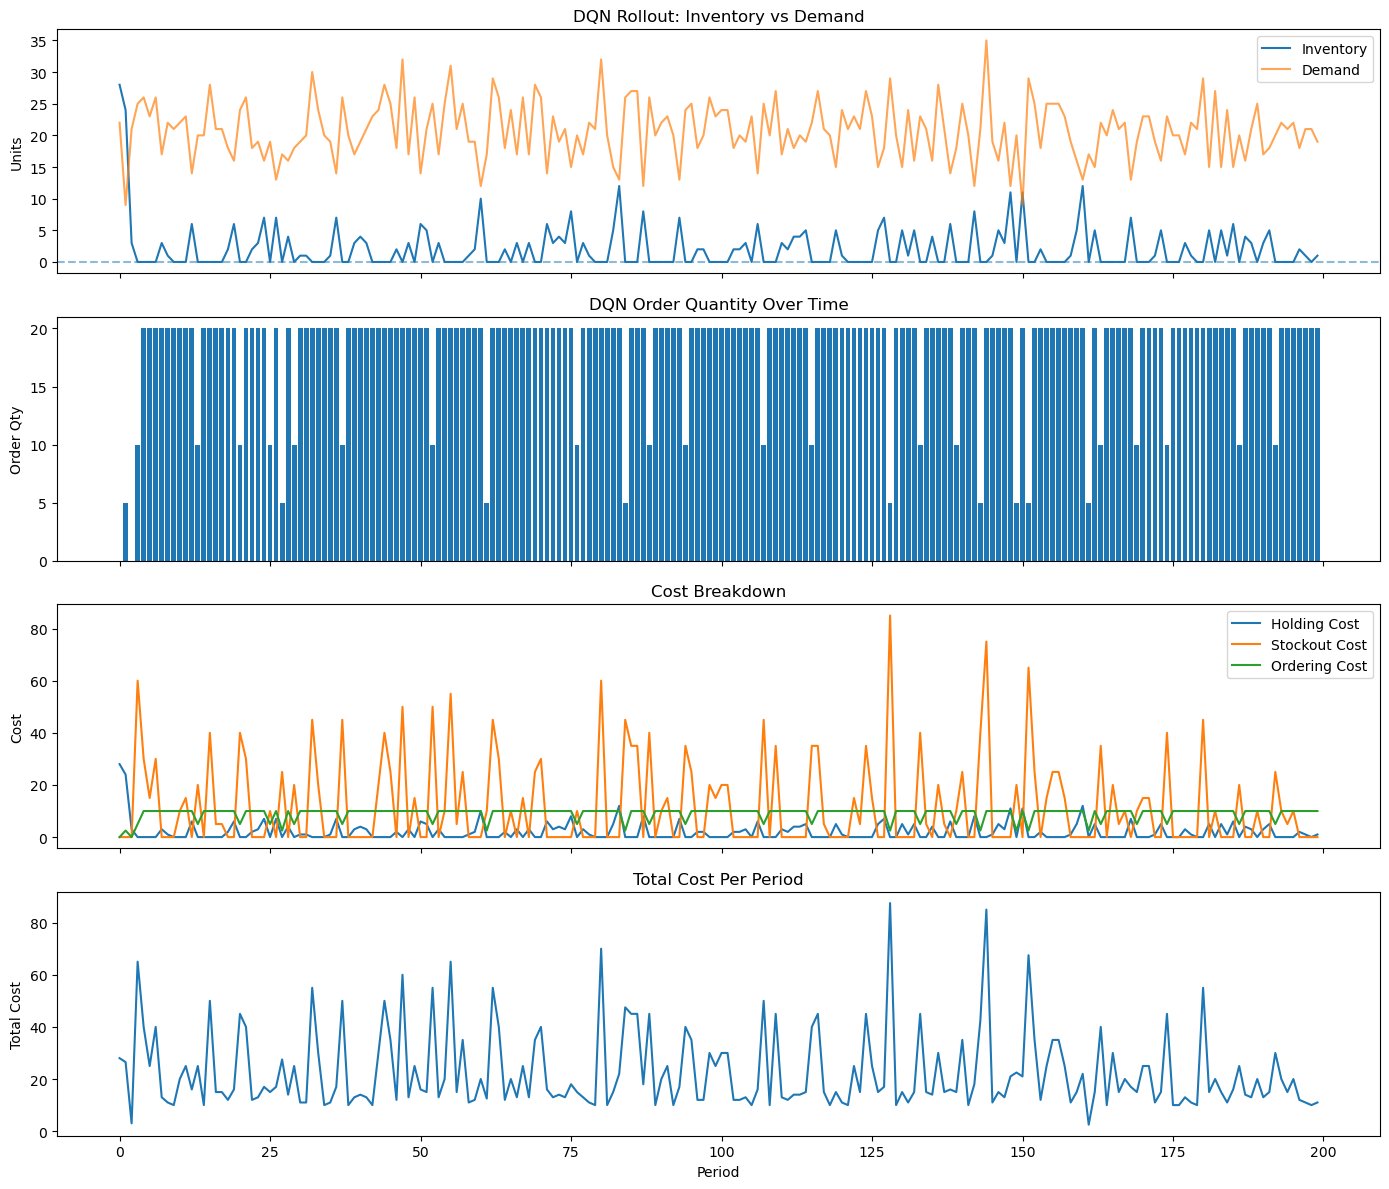

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# -----------------------------
# 1. Run one DQN episode
# -----------------------------
dqn_episode = run_episode(
    env=make_stationary_env(),
    policy_fn=dqn_stationary_policy,
    seed=0
)


# -----------------------------
# 2. Print summary
# -----------------------------
print("--- DQN Episode Summary ---")
print(f"Total cost:        {dqn_episode['total_cost']:.2f}")
print(f"Holding cost:      {sum(dqn_episode['holding_costs']):.2f}")
print(f"Stockout cost:     {sum(dqn_episode['stockout_costs']):.2f}")
print(f"Ordering cost:     {sum(dqn_episode['ordering_costs']):.2f}")
print(f"Stockout periods:  {dqn_episode['stockout_periods']}/{len(dqn_episode['demands'])}")
print(f"Service level:     {100 * dqn_episode['service_level']:.1f}%")
print(f"Avg inventory:     {dqn_episode['avg_inventory']:.2f}")
print(f"Avg order qty:     {np.mean(dqn_episode['orders']):.2f}")


# -----------------------------
# 3. Convert episode to dataframe
# -----------------------------
dqn_rollout_df = pd.DataFrame({
    "period": np.arange(len(dqn_episode["demands"])),
    "inventory": dqn_episode["inventories"],
    "demand": dqn_episode["demands"],
    "order_qty": dqn_episode["orders"],
    "holding_cost": dqn_episode["holding_costs"],
    "stockout_cost": dqn_episode["stockout_costs"],
    "ordering_cost": dqn_episode["ordering_costs"],
})

dqn_rollout_df["total_period_cost"] = (
    dqn_rollout_df["holding_cost"]
    + dqn_rollout_df["stockout_cost"]
    + dqn_rollout_df["ordering_cost"]
)

display(dqn_rollout_df.head(20))


# -----------------------------
# 4. Plot inventory, demand, orders, and costs
# -----------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Inventory and demand
axes[0].plot(dqn_rollout_df["period"], dqn_rollout_df["inventory"], label="Inventory")
axes[0].plot(dqn_rollout_df["period"], dqn_rollout_df["demand"], label="Demand", alpha=0.7)
axes[0].axhline(y=0, linestyle="--", alpha=0.5)
axes[0].set_ylabel("Units")
axes[0].set_title("DQN Rollout: Inventory vs Demand")
axes[0].legend()

# Orders
axes[1].bar(dqn_rollout_df["period"], dqn_rollout_df["order_qty"])
axes[1].set_ylabel("Order Qty")
axes[1].set_title("DQN Order Quantity Over Time")

# Cost breakdown
axes[2].plot(dqn_rollout_df["period"], dqn_rollout_df["holding_cost"], label="Holding Cost")
axes[2].plot(dqn_rollout_df["period"], dqn_rollout_df["stockout_cost"], label="Stockout Cost")
axes[2].plot(dqn_rollout_df["period"], dqn_rollout_df["ordering_cost"], label="Ordering Cost")
axes[2].set_ylabel("Cost")
axes[2].set_title("Cost Breakdown")
axes[2].legend()

# Total cost per period
axes[3].plot(dqn_rollout_df["period"], dqn_rollout_df["total_period_cost"])
axes[3].set_ylabel("Total Cost")
axes[3].set_xlabel("Period")
axes[3].set_title("Total Cost Per Period")

plt.tight_layout()
plt.show()

,order_qty,count,percentage
0,0,2,1.0
1,5,9,4.5
2,10,19,9.5
3,20,170,85.0


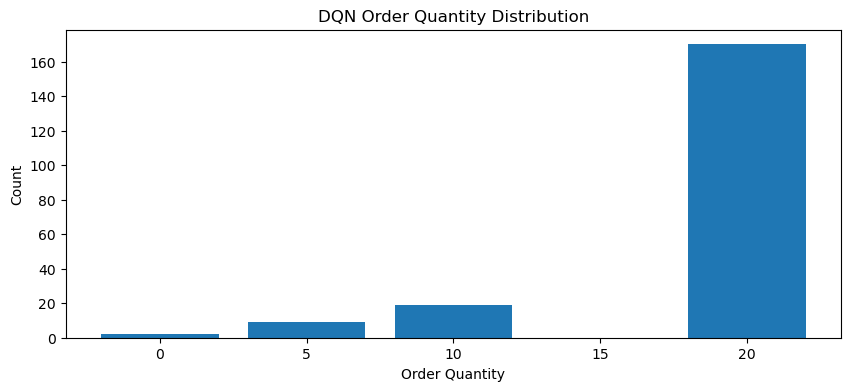

In [13]:
#  DQN order quantity distribution
order_counts = dqn_rollout_df["order_qty"].value_counts().sort_index()

order_distribution_df = pd.DataFrame({
    "order_qty": order_counts.index,
    "count": order_counts.values,
    "percentage": 100 * order_counts.values / order_counts.values.sum()
})

display(order_distribution_df)

plt.figure(figsize=(10, 4))
plt.bar(order_distribution_df["order_qty"], order_distribution_df["count"], width=4)
plt.xlabel("Order Quantity")
plt.ylabel("Count")
plt.title("DQN Order Quantity Distribution")
plt.show()

### Reusable DQN training function 

In [15]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed

import numpy as np
import random
import torch


def make_monitored_env(env_factory, seed=42):
    """
    Create a monitored environment for Stable-Baselines3 training.
    """
    env = env_factory()
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return Monitor(env)


def train_dqn_agent(
    env_factory,
    model_name="dqn_inventory",
    total_timesteps=100_000,
    seed=42,
    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.3,
    exploration_final_eps=0.05,
    verbose=1,
):
    """
    Train a DQN agent on one inventory environment.

    Parameters
    ----------
    env_factory : callable
        Example: make_stationary_env, make_seasonal_env, make_trend_env
    model_name : str
        Name used when saving the trained model.
    total_timesteps : int
        Number of environment steps for training.
    seed : int
        Random seed.

    Returns
    -------
    model : stable_baselines3.DQN
        Trained DQN model.
    """

    # Reproducibility
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    set_random_seed(seed)

    # Environment
    env = make_monitored_env(env_factory, seed=seed)

    # DQN model
    model = DQN(
        policy="MlpPolicy",
        env=env,
        learning_rate=learning_rate,
        buffer_size=buffer_size,
        learning_starts=learning_starts,
        batch_size=batch_size,
        gamma=gamma,
        train_freq=4,
        target_update_interval=1_000,
        exploration_fraction=exploration_fraction,
        exploration_initial_eps=1.0,
        exploration_final_eps=exploration_final_eps,
        verbose=verbose,
        seed=seed,
    )

    # Train
    model.learn(total_timesteps=total_timesteps)

    # Save
    model.save(model_name)
    print(f"Saved trained model to {model_name}.zip")

    return model


def make_dqn_policy(model):
    """
    Convert a trained SB3 DQN model into a policy function compatible with compare_policies().
    """
    def policy_fn(obs):
        action, _ = model.predict(obs, deterministic=True)
        return int(action)

    return policy_fn

In [16]:
# Train reusable stationary DQN
dqn_stationary_v2 = train_dqn_agent(
    env_factory=make_stationary_env,
    model_name="dqn_stationary_inventory_v2",
    total_timesteps=100_000,
    seed=42,
    verbose=1,
)

dqn_stationary_v2_policy = make_dqn_policy(dqn_stationary_v2)

Using cuda device
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -4.02e+04 |
|    exploration_rate | 0.975     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 30063     |
|    time_elapsed     | 0         |
|    total_timesteps  | 800       |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -3.99e+04 |
|    exploration_rate | 0.949     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 4338      |
|    time_elapsed     | 0         |
|    total_timesteps  | 1600      |
| train/              |           |
|    learning_rate    | 0.001     |
|    loss             | 5.54      |
|    n_updates        | 149       |
-----------------------------------
-----------

In [17]:
# Evaluate reusable stationary DQN

stationary_v2_results = compare_policies(
    env_factory=make_stationary_env,
    policies={
        "DQN stationary v2": dqn_stationary_v2_policy,
        "DQN previous": dqn_stationary_policy,
        "Random": random_policy,
        "Always order 20": always_order_20_policy,
        "Always order 25": always_order_25_policy,
        "Always order 30": always_order_30_policy,
    },
    n_episodes=30,
    seeds=list(range(30)),
)

Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN stationary v2          4138.7      152.1      55.8%        2.2
DQN previous               4311.5      184.8      54.6%        2.2
Random                    39883.2      528.6     100.0%      174.5
Always order 20           11599.4     4817.8      97.9%       47.6
Always order 25           36679.0      357.0     100.0%      170.9
Always order 30           38177.8      150.8     100.0%      175.9


## Train DQN on seasonal and trend demand

In [18]:
# Train DQN on seasonal demand
dqn_seasonal = train_dqn_agent(
    env_factory=make_seasonal_env,
    model_name="dqn_seasonal_inventory",
    total_timesteps=100_000,
    seed=42,
    verbose=1,
)

dqn_seasonal_policy = make_dqn_policy(dqn_seasonal)


# Train DQN on trend demand
dqn_trend = train_dqn_agent(
    env_factory=make_trend_env,
    model_name="dqn_trend_inventory",
    total_timesteps=100_000,
    seed=42,
    verbose=1,
)

dqn_trend_policy = make_dqn_policy(dqn_trend)

Using cuda device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 200      |
|    ep_rew_mean      | -4e+04   |
|    exploration_rate | 0.975    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 25583    |
|    time_elapsed     | 0        |
|    total_timesteps  | 800      |
----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -3.96e+04 |
|    exploration_rate | 0.949     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 3994      |
|    time_elapsed     | 0         |
|    total_timesteps  | 1600      |
| train/              |           |
|    learning_rate    | 0.001     |
|    loss             | 7.37      |
|    n_updates        | 149       |
-----------------------------------
----------------------

In [19]:
# Evaluate trained DQNs on matching scenarios

def results_to_df(results, scenario_name):
    rows = []

    for policy_name, metrics in results.items():
        rows.append({
            "scenario": scenario_name,
            "policy": policy_name,
            "avg_total_cost": metrics["avg_total_cost"],
            "std_total_cost": metrics["std_total_cost"],
            "avg_service_level": metrics["avg_service_level"],
            "avg_stockout_periods": metrics["avg_stockout_periods"],
            "avg_inventory": metrics["avg_inventory"],
        })

    return pd.DataFrame(rows)


# Stationary evaluation
stationary_eval = compare_policies(
    env_factory=make_stationary_env,
    policies={
        "DQN trained on stationary": dqn_stationary_v2_policy,
        "Random": random_policy,
        "Always order 20": always_order_20_policy,
        "Always order 25": always_order_25_policy,
    },
    n_episodes=30,
    seeds=list(range(30)),
)

stationary_eval_df = results_to_df(stationary_eval, "Stationary")


# Seasonal evaluation
seasonal_eval = compare_policies(
    env_factory=make_seasonal_env,
    policies={
        "DQN trained on seasonal": dqn_seasonal_policy,
        "DQN trained on stationary": dqn_stationary_v2_policy,
        "Random": random_policy,
        "Always order 20": always_order_20_policy,
        "Always order 25": always_order_25_policy,
    },
    n_episodes=30,
    seeds=list(range(30)),
)

seasonal_eval_df = results_to_df(seasonal_eval, "Seasonal")


# Trend evaluation
trend_eval = compare_policies(
    env_factory=make_trend_env,
    policies={
        "DQN trained on trend": dqn_trend_policy,
        "DQN trained on stationary": dqn_stationary_v2_policy,
        "Random": random_policy,
        "Always order 20": always_order_20_policy,
        "Always order 25": always_order_25_policy,
    },
    n_episodes=30,
    seeds=list(range(30)),
)

trend_eval_df = results_to_df(trend_eval, "Trend")


# Combine all evaluation results
dqn_scenario_summary_df = pd.concat(
    [stationary_eval_df, seasonal_eval_df, trend_eval_df],
    ignore_index=True
)

dqn_scenario_summary_df = dqn_scenario_summary_df.sort_values(
    ["scenario", "avg_total_cost"]
)

dqn_scenario_summary_df

Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN trained on stationary       4138.7      152.1      55.8%        2.2
Random                    39883.2      528.6     100.0%      174.5
Always order 20           11599.4     4817.8      97.9%       47.6
Always order 25           36679.0      357.0     100.0%      170.9
Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN trained on seasonal       4009.6      143.1      77.5%        5.5
DQN trained on stationary       6801.5      224.7      50.2%        7.0
Random                    39798.6      421.6     100.0%      173.9
Always order 20           18207.9     1451.1      89.2%       77.0
Always order 25           30633.8      756.4      99.1%      140.4
Policy                 Total Cost      ± Std  Service %    Avg Inv
---------------------------------------------------

,scenario,policy,avg_total_cost,std_total_cost,avg_service_level,avg_stockout_periods,avg_inventory
4,Seasonal,DQN trained on seasonal,4009.600000,143.113149,0.775167,44.966667,5.456333
5,Seasonal,DQN trained on stationary,6801.483333,224.737865,0.501833,99.633333,7.004500
7,Seasonal,Always order 20,18207.866667,1451.097418,0.891833,21.633333,77.036833
8,Seasonal,Always order 25,30633.833333,756.379802,0.990833,1.833333,140.439167
6,Seasonal,Random,39798.600000,421.599976,0.999833,0.033333,173.920500
0,Stationary,DQN trained on stationary,4138.683333,152.061692,0.558333,88.333333,2.239667
2,Stationary,Always order 20,11599.433333,4817.848543,0.978500,4.300000,47.614667
3,Stationary,Always order 25,36679.000000,356.963303,1.000000,0.000000,170.895000
1,Stationary,Random,39883.233333,528.633864,0.999833,0.033333,174.495333
9,Trend,DQN trained on trend,5299.966667,195.931575,0.556167,88.766667,2.859000


### Cross-scenario DQN evaluation

In [20]:
# Environment factories
scenario_envs = {
    "Stationary": make_stationary_env,
    "Seasonal": make_seasonal_env,
    "Trend": make_trend_env,
}

# Trained DQN policies
dqn_policy_dict = {
    "DQN trained on stationary": dqn_stationary_v2_policy,
    "DQN trained on seasonal": dqn_seasonal_policy,
    "DQN trained on trend": dqn_trend_policy,
}

cross_eval_dfs = []

for scenario_name, env_factory in scenario_envs.items():
    print(f"\n==============================")
    print(f"Evaluating on {scenario_name} environment")
    print(f"==============================")

    results = compare_policies(
        env_factory=env_factory,
        policies=dqn_policy_dict,
        n_episodes=30,
        seeds=list(range(30)),
    )

    scenario_df = results_to_df(results, scenario_name)
    cross_eval_dfs.append(scenario_df)

cross_dqn_summary_df = pd.concat(cross_eval_dfs, ignore_index=True)

cross_dqn_summary_df = cross_dqn_summary_df.sort_values(
    ["scenario", "avg_total_cost"]
)

cross_dqn_summary_df


Evaluating on Stationary environment
Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN trained on stationary       4138.7      152.1      55.8%        2.2
DQN trained on seasonal       3932.3      129.7      73.9%        4.8
DQN trained on trend       3754.5      138.4      66.7%        3.0

Evaluating on Seasonal environment
Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN trained on stationary       6801.5      224.7      50.2%        7.0
DQN trained on seasonal       4009.6      143.1      77.5%        5.5
DQN trained on trend       4384.1      148.1      67.5%        4.1

Evaluating on Trend environment
Policy                 Total Cost      ± Std  Service %    Avg Inv
-----------------------------------------------------------------
DQN trained on stationary       8410.1      300.4      28.3%        1.3
DQN 

,scenario,policy,avg_total_cost,std_total_cost,avg_service_level,avg_stockout_periods,avg_inventory
4,Seasonal,DQN trained on seasonal,4009.600000,143.113149,0.775167,44.966667,5.456333
5,Seasonal,DQN trained on trend,4384.083333,148.106723,0.674667,65.066667,4.130833
3,Seasonal,DQN trained on stationary,6801.483333,224.737865,0.501833,99.633333,7.004500
2,Stationary,DQN trained on trend,3754.483333,138.365668,0.666667,66.666667,2.998667
1,Stationary,DQN trained on seasonal,3932.333333,129.688623,0.738833,52.233333,4.816667
0,Stationary,DQN trained on stationary,4138.683333,152.061692,0.558333,88.333333,2.239667
7,Trend,DQN trained on seasonal,4893.666667,216.092971,0.682667,63.466667,4.712500
8,Trend,DQN trained on trend,5299.966667,195.931575,0.556167,88.766667,2.859000
6,Trend,DQN trained on stationary,8410.100000,300.441131,0.282833,143.433333,1.290500


In [22]:
# Create cost and service-level matrices

cost_matrix = cross_dqn_summary_df.pivot(
    index="scenario",
    columns="policy",
    values="avg_total_cost"
)

service_matrix = cross_dqn_summary_df.pivot(
    index="scenario",
    columns="policy",
    values="avg_service_level"
)

inventory_matrix = cross_dqn_summary_df.pivot(
    index="scenario",
    columns="policy",
    values="avg_inventory"
)

print("Average Total Cost Matrix")
display(cost_matrix)

print("Average Service Level Matrix")
display(service_matrix)

print("Average Inventory Matrix")
display(inventory_matrix)

Average Total Cost Matrix


policy,DQN trained on seasonal,DQN trained on stationary,DQN trained on trend
scenario,,,
Seasonal,4009.600000,6801.483333,4384.083333
Stationary,3932.333333,4138.683333,3754.483333
Trend,4893.666667,8410.100000,5299.966667


Average Service Level Matrix


policy,DQN trained on seasonal,DQN trained on stationary,DQN trained on trend
scenario,,,
Seasonal,0.775167,0.501833,0.674667
Stationary,0.738833,0.558333,0.666667
Trend,0.682667,0.282833,0.556167


Average Inventory Matrix


policy,DQN trained on seasonal,DQN trained on stationary,DQN trained on trend
scenario,,,
Seasonal,5.456333,7.004500,4.130833
Stationary,4.816667,2.239667,2.998667
Trend,4.712500,1.290500,2.859000


In [23]:
cross_dqn_summary_df.to_csv("dqn_cross_scenario_summary.csv", index=False)
cost_matrix.to_csv("dqn_cost_matrix.csv")
service_matrix.to_csv("dqn_service_level_matrix.csv")
inventory_matrix.to_csv("dqn_inventory_matrix.csv")

print("Saved:")
print("- dqn_cross_scenario_summary.csv")
print("- dqn_cost_matrix.csv")
print("- dqn_service_level_matrix.csv")
print("- dqn_inventory_matrix.csv")

Saved:
- dqn_cross_scenario_summary.csv
- dqn_cost_matrix.csv
- dqn_service_level_matrix.csv
- dqn_inventory_matrix.csv


## Person 2: RL Agent Implementation with DQN

This section implements the reinforcement learning agent for the inventory simulator.  
We use Deep Q-Networks because the inventory environment has a discrete action space, where each action corresponds to an order quantity.

Three DQN agents were trained:

1. DQN trained on stationary demand
2. DQN trained on seasonal demand
3. DQN trained on trend demand

Each trained model was wrapped into a policy function compatible with the existing `compare_policies()` evaluation utility.

The main finding is that DQN agents trained under non-stationary demand generalize better than the DQN trained only under stationary demand. In particular, the seasonal-trained DQN achieves the lowest cost in both the seasonal and trend evaluation scenarios.

## InventoryEnv — API Reference

### Observation Space (6 floats)
| Index | Field | Range | Description |
|-------|-------|-------|-------------|
| 0 | `inventory` | 0 to 200 | Current inventory level after sales |
| 1–4 | `demand_history` | ≥ 0 | Last 4 periods of realized demand (oldest → newest) |
| 5 | `time_feature` | 0.0 to 1.0 | Current period / episode length |

### Action Space (21 discrete actions)
| Action index | Order quantity |
|-------------|---------------|
| 0 | 0 units |
| 1 | 5 units |
| 2 | 10 units |
| ... | ... |
| 20 | 100 units |

**Mapping:** `env.action_to_quantity[action]` gives the actual order quantity.

### Reward
`reward = -(holding_cost + stockout_cost + ordering_cost)` per period.

| Cost component | Rate | Applied to |
|---------------|------|------------|
| Holding | $1.0 / unit | Unsold inventory at end of period |
| Stockout | $5.0 / unit | Unmet demand (lost sales) |
| Ordering | $0.5 / unit | Units ordered |

### Presets
| Function | Demand type | Use for |
|----------|-------------|---------|
| `make_stationary_env()` | Poisson(20) | Baseline — RL vs newsvendor under simple demand |
| `make_seasonal_env()` | Poisson(20 ± 10, period=50) | Extension — does RL adapt to cycles? |
| `make_trend_env()` | Poisson(15 + 0.1t) | Extension — does RL adapt to drift? |

### Writing a Policy Function (Person 3)
```python
def newsvendor_policy(obs):
    # obs[0] = current inventory, obs[1:5] = demand history
    # Return an integer action index (0–20)
    target_order = ...  # your newsvendor logic
    # Find closest action
    closest = min(range(len(env.action_to_quantity)),
                  key=lambda i: abs(env.action_to_quantity[i] - target_order))
    return closest
```

### Running Evaluations (Person 4)
```python
results = compare_policies(
    env_factory=make_seasonal_env,
    policies={"DQN": dqn_policy, "Newsvendor": nv_policy, "Random": random_policy},
    n_episodes=20,
)
# results["DQN"]["all_episodes"] has per-period data for detailed plots
```